# So
# FGT: Spot 2
# CrSBr: Spot 3, but also spot 1 & 6 (no FGT signal)
# hBN: Spot 5, also spot 4, but with an large background signal due to some polymer residues on top


In [7]:
import sys as _sys
from pathlib import Path as _Path
try:
    _sys.path.insert(0, str(_Path(__vsc_ipynb_file__).parent.parent))
except NameError:
    pass  # Not in VS Code; rely on pip install -e .

import os
from scripts.utils import setup_notebook, OKABE_ITO_CYCLE

PROJECT_ROOT, np, pd, plt, Path = setup_notebook()

# Backward-compatible alias
color_values = OKABE_ITO_CYCLE

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[OK] Autoreload enabled
[OK] Project root: c:\Users\sadit\OneDrive - JGU\Projects\EB-in FGT-CrSBr
[OK] Matplotlib configured (Okabe-Ito palette, publication style)
Setup complete!


In [8]:
class RamanSpectrum:
    def __init__(self, filepath, label, start_n = 0):
        self.filepath = filepath
        self.label = label
        self.data = self._read_file()
        self.wavenumber = self.data.iloc[:, 0].to_numpy()
        self.counts = self.data.iloc[:, 1].to_numpy()
        idx = np.where(start_n <= self.wavenumber)
        self.wavenumber = self.wavenumber[idx]
        self.counts = self.counts[idx]

    def _read_file(self):
        return pd.read_csv(self.filepath, delimiter='\t', skiprows = 16, encoding='latin1')

In [9]:
RAW_DATA_DIR = PROJECT_ROOT / "data" / "Raman"
PLOTS_DIR    = PROJECT_ROOT / "figures"
PLOTS_DIR.mkdir(exist_ok=True)

custom_keys = {
    "Spot 1 2 mW.txt": "CrSBr 1",
}

spectra = {}
for filename, label in custom_keys.items():
    filepath = RAW_DATA_DIR / filename
    spectra[label] = RamanSpectrum(filepath, label, start_n=50)

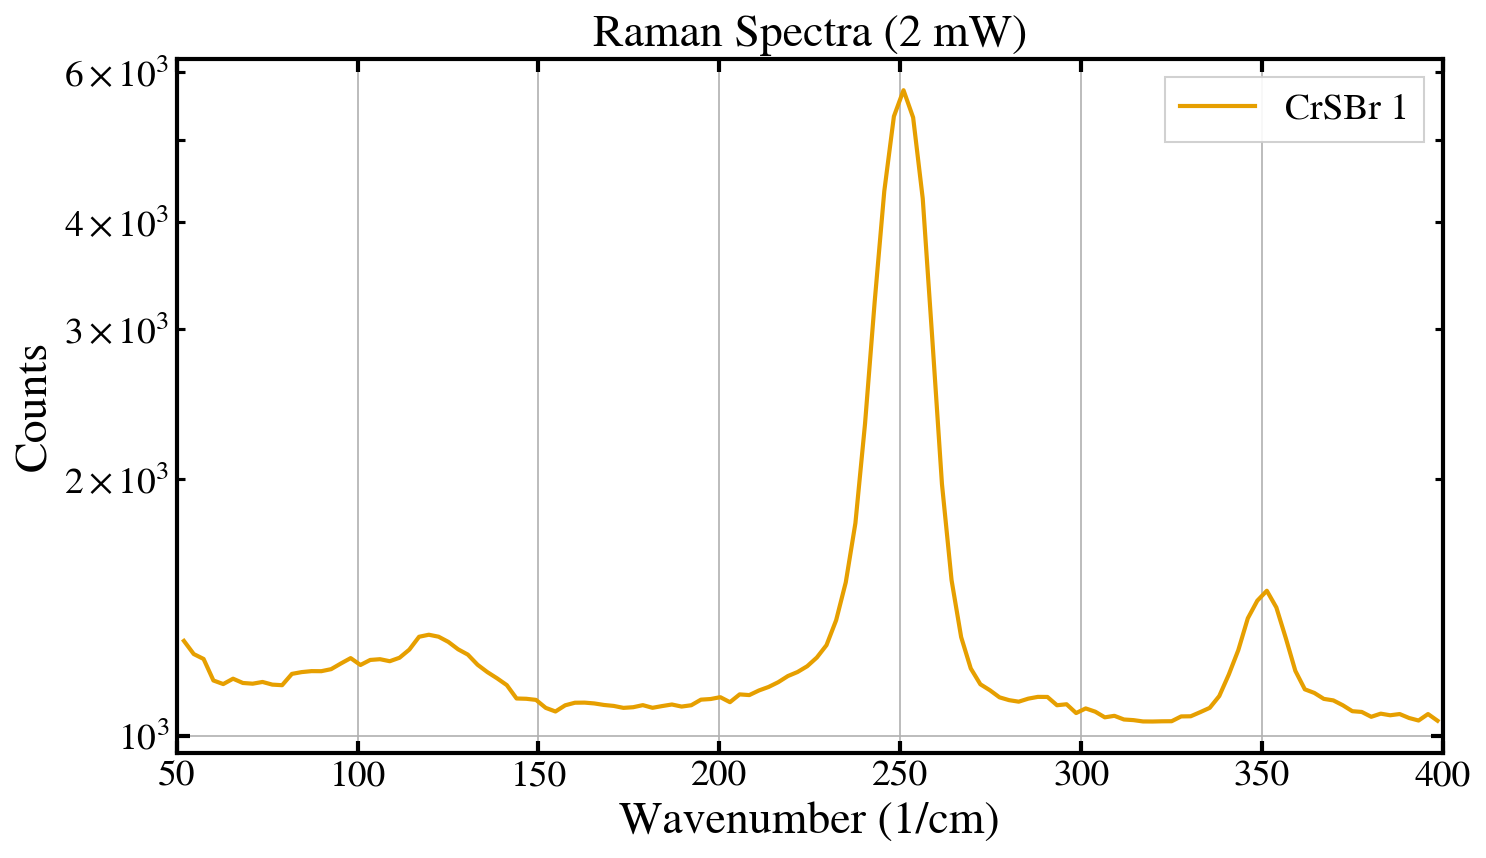

In [11]:
plt.figure(figsize=(10, 6))
start = 50
stop = 400

plt.xlabel("Wavenumber (1/cm)")
plt.ylabel("Counts")
plt.title("Raman Spectra (2 mW)")

mask = (spectra["CrSBr 1"].wavenumber > start) & (spectra["CrSBr 1"].wavenumber < stop)
plt.semilogy(spectra["CrSBr 1"].wavenumber[mask], spectra["CrSBr 1"].counts[mask], label=label)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlim([50,400])
# plt.ylim([500, 800])
plt.show()

   Raman Frequency (cm-1)  Intensity (a.u)
0                85.61765          0.75395
1                88.37340          0.75363
2                91.12820          0.76336
3                93.88205          0.77569
4                96.63496          0.77501


C:\Windows\Temp\ipykernel_29260\2985247148.py:14: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) STIXGeneral.
  plt.tight_layout()
c:\Users\sadit\anaconda3\envs\data_analysis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) STIXGeneral.
  fig.canvas.print_figure(bytes_io, **kw)


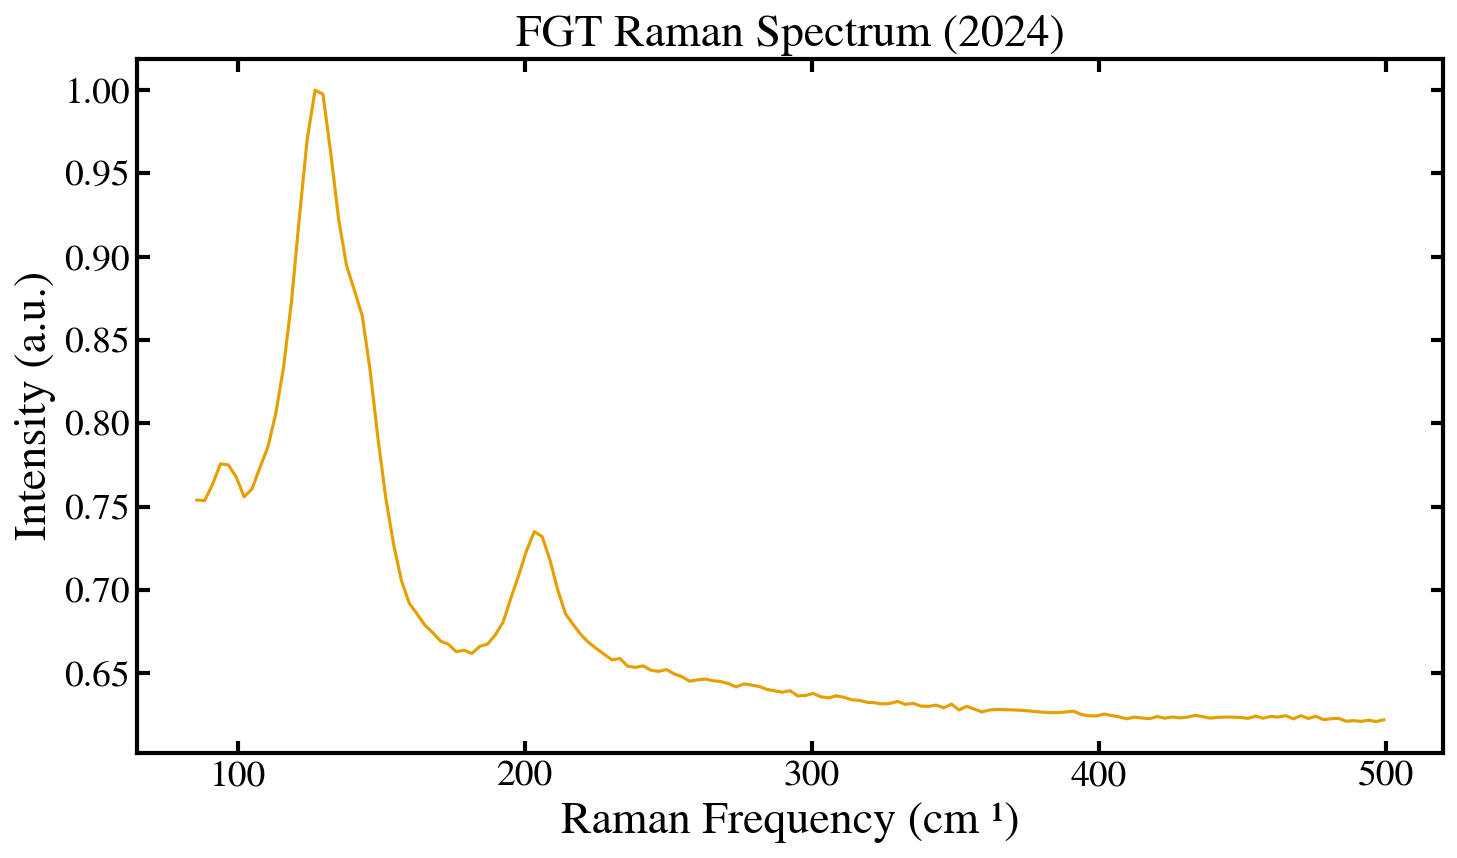

In [12]:
# Load the data
file_path = os.path.join(RAW_DATA_DIR,"FGT_Raman_2024.txt")
df = pd.read_csv(file_path, sep="\t")

# Display the first few rows to confirm
print(df.head())

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(df['Raman Frequency (cm-1)'], df['Intensity (a.u)'], linewidth=1.5, color = color_values[0])
plt.title('FGT Raman Spectrum (2024)')
plt.xlabel('Raman Frequency (cm⁻¹)')
plt.ylabel('Intensity (a.u.)')
plt.tight_layout()
plt.show()


In [13]:
CrSBr_norm = spectra["CrSBr 1"].counts / np.max(spectra["CrSBr 1"].counts[mask])

C:\Windows\Temp\ipykernel_29260\3700805650.py:6: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) STIXGeneral.
  plt.tight_layout()
C:\Windows\Temp\ipykernel_29260\3700805650.py:9: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) STIXGeneral.
  plt.savefig(os.path.join(PLOTS_DIR, 'Raman_FGT_bulk_and_CrSBr_flake.png'))


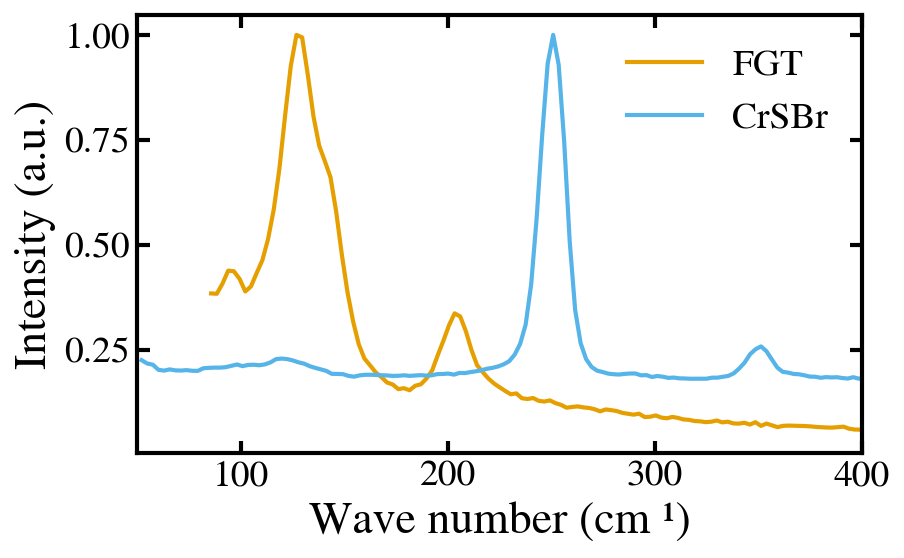

In [14]:
plt.figure(figsize=(6, 4))
plt.plot(df['Raman Frequency (cm-1)'], (df['Intensity (a.u)'] - 0.6)/0.4, label = 'FGT', color = color_values[0])
plt.plot(spectra['CrSBr 1'].wavenumber, CrSBr_norm, label = 'CrSBr' , color = color_values[1])
plt.xlabel('Wave number (cm⁻¹)')
plt.ylabel('Intensity (a.u.)')
plt.tight_layout()
plt.xlim([50,400])
plt.legend(frameon=False)
plt.savefig(os.path.join(PLOTS_DIR, 'Raman_FGT_bulk_and_CrSBr_flake.png'))
plt.show()